# The NTK evolution operator and its contributions (PDF space)

Builds the `EvolutionOperator` via the `produce_evolution_operator` production and
shows how to plot its pieces in PDF space.

The operator is the linearised training dynamics, with the NTK evaluated at a
**reference epoch** (the "reference time"). The evolved solution is

$$ f(t) = \underbrace{U(t)\,f_0}_{\text{network part}} + \underbrace{V(t)\,\text{data}}_{\text{data part}} $$

so the quantities we can plot are:
- the **full solution** `plotting_grid(t, data, f0)`,
- the **U contribution** `plotting_grid_u(t, f0)` (how the initial function is transported),
- the **V contribution** `plotting_grid_v(t, data)` (what the data injects),

for different choices of `f0` (network at initialisation, or network at the reference
epoch). Each is an `XPlottingGrid` with replicas on axis 0, so we draw the **ensemble**
band with `plot_grids(..., plot_provider="bounds")` and a **single replica** with
`plot_provider="line"` + `replicas=[r]`.

In [1]:
%matplotlib inline
from IPython.display import display

from ntkpdf.api import API
from ntkpdf.plotting.pdfplots_providers import DEFAULT_FLAVOURS, DEFAULT_YLABELS
from ntkpdf.plotting.pdfplots_utils import plot_grids
from ntkpdf.utils import EVOL_LIST

import logging
logging.basicConfig(level=logging.INFO)

Applying NTKPDF plotting style...
Using Keras backend


In [2]:
# Minimal data/theory context the FK / NTK chain needs.
common_dict = dict(
    dataset_inputs={"from_": "fit"},
    use_cuts="fromfit",
    theory={"from_": "fit"},
    theoryid={"from_": "theory"},
)
fit = "260526-ac-02-ntk-sgd"
reference_epoch = 5000   # epoch with saved weights -> NTK is linearised here

In [3]:
# The evolution operator at the reference epoch (the production rule). It is
# time-independent; the evolution time t is passed to its methods below.
evo = API.evolution_operator(
    fit=fit, **common_dict,
    name="model", 
    epoch=reference_epoch, 
    evol_fl_names=list(EVOL_LIST), training=True,
)

# Ingredients for the evolution: f0 (two choices), the training data, the learning
# rate, and the evolution time t = (#epochs) * lr to evolve up to the reference time.
f0_init = API.pdf_at_init(fit=fit, **common_dict)                          # network at init
f0_ref = API.pdf_at_epoch(fit=fit, **common_dict, epoch=reference_epoch)   # network at reference epoch
data_tr, _ = API.get_train_val_data(fit=fit, **common_dict)
lr = API.learning_rate(fit=fit)
t = reference_epoch * lr
print(f"learning_rate={lr:.2e}  ->  evolution time t={t:.3e}")

Computing eigenvectors:   0%|          | 0/3 [00:00<?, ?it/s]INFO:2026-06-11 12:38:05,124:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)
Computing eigenvectors: 100%|██████████| 3/3 [00:13<00:00,  4.38s/it]


/opt/homebrew/Caskroom/miniconda/base/envs/colibri-dev/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'NN_input': 'NN_input'}
Received: inputs=Tensor(shape=(1, 50, 2))
  warnings.warn(msg)


learning_rate=1.00e-06  ->  evolution time t=5.000e-03


## Full solution and its U / V contributions (ensemble)

With `f0 = ` network at initialisation. The full solution is the sum of the two
contributions.

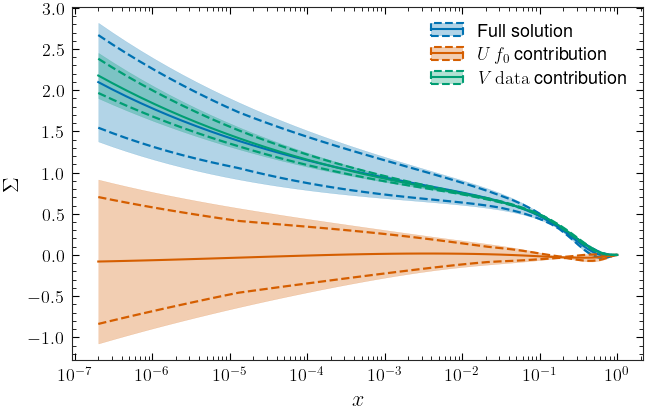

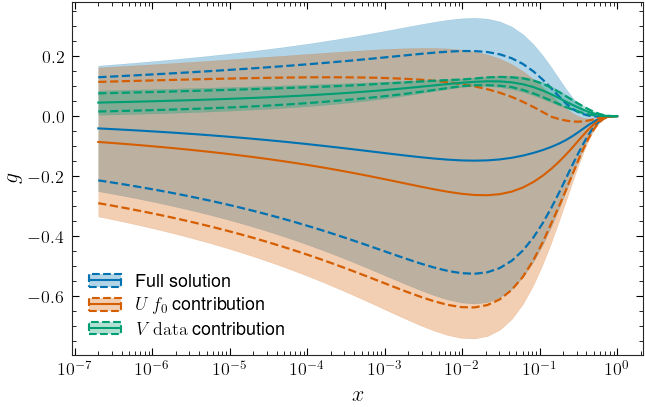

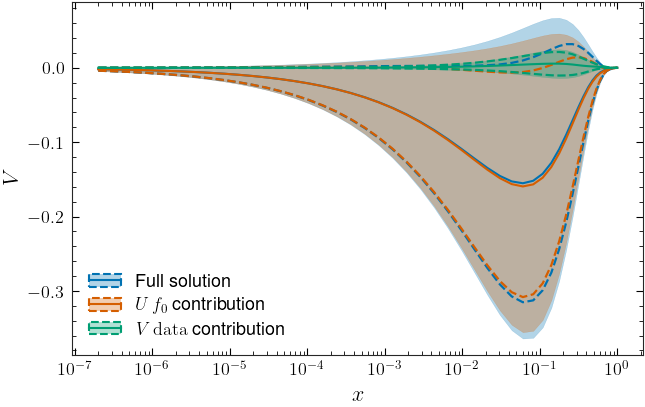

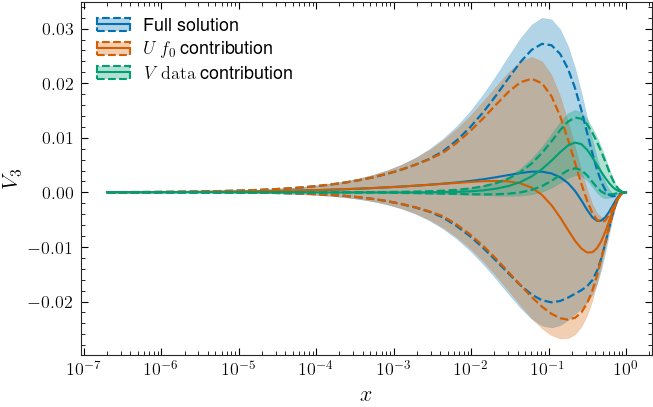

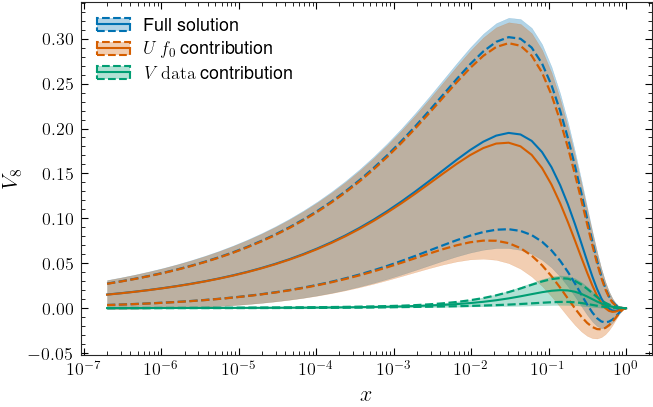

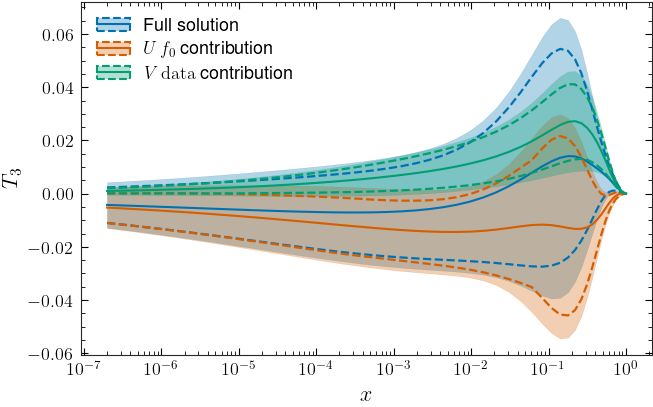

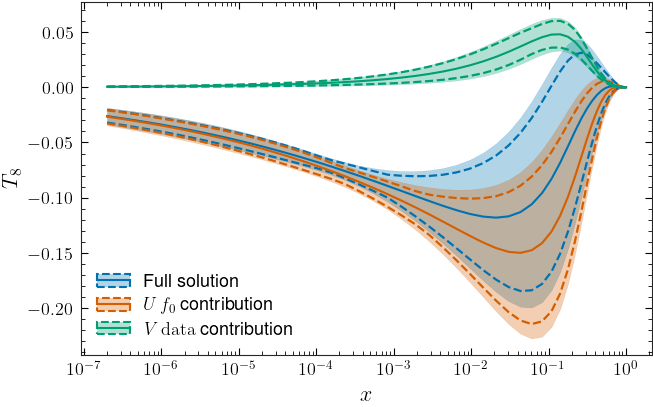

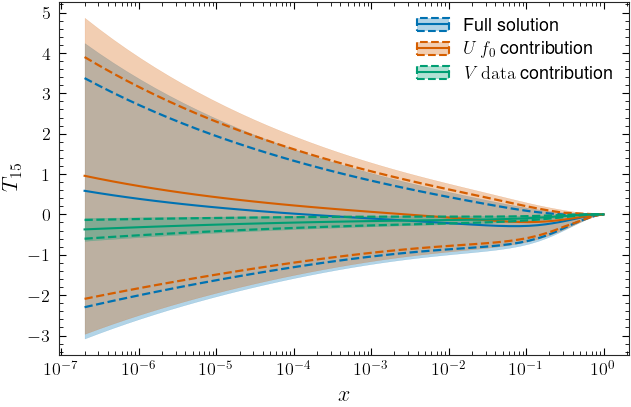

In [4]:
full = evo.plotting_grid(t, data_tr, f0_init)
u_contrib = evo.plotting_grid_u(t, f0_init)
v_contrib = evo.plotting_grid_v(t, data_tr)

figs = list(plot_grids(
    [full, u_contrib, v_contrib],
    flavours=DEFAULT_FLAVOURS,
    ylabels=DEFAULT_YLABELS,
    labels=["Full solution", r"$U\,f_0$ contribution", r"$V\,\mathrm{data}$ contribution"],
    plot_provider="bounds",   # ensemble band over replicas
    xscale="log",
))
for fig in figs:
    display(fig)

## Same, but for a single replica

Identical grids, drawn as individual lines for one replica (`replicas=[r]`, 1-based)
instead of the ensemble band.

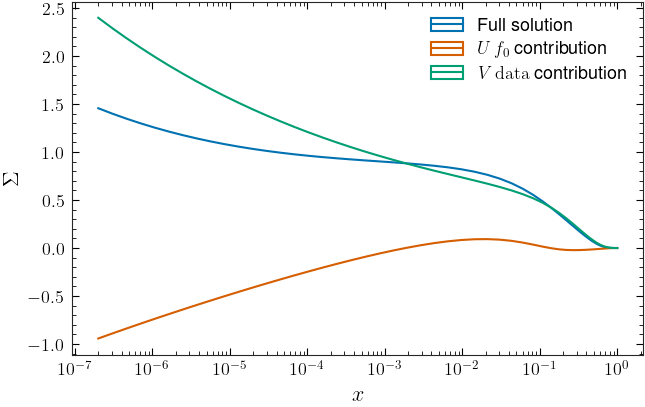

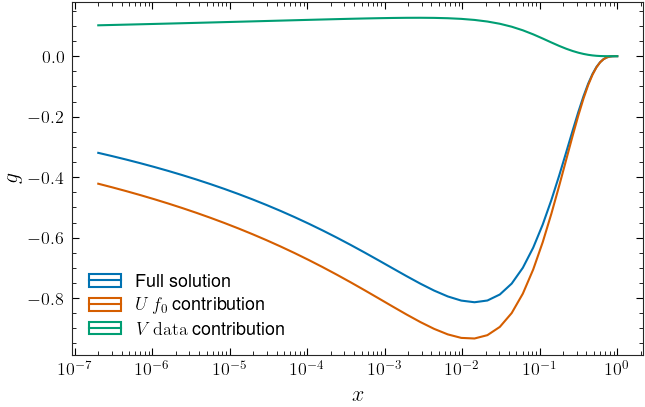

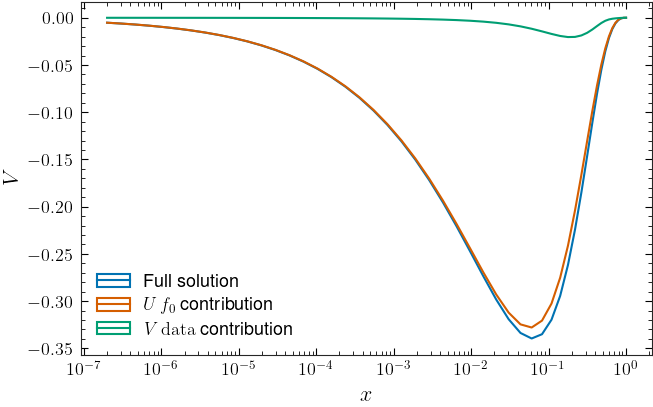

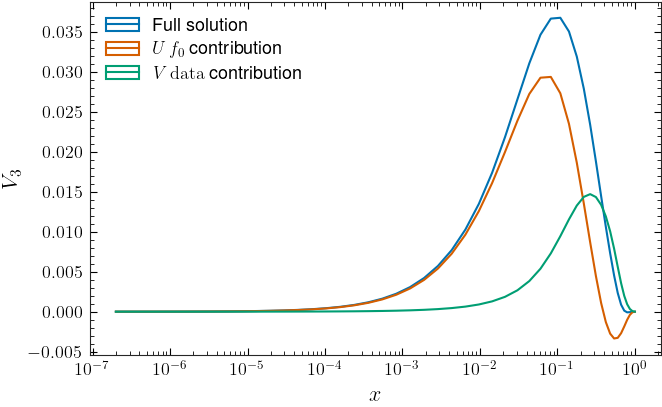

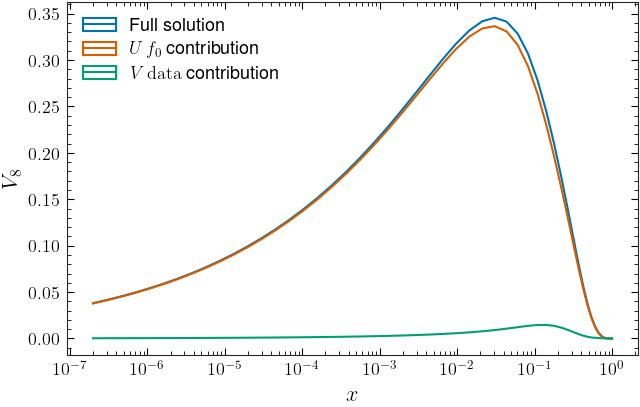

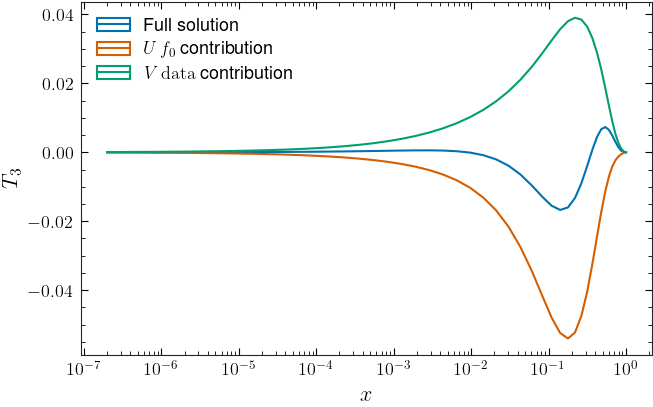

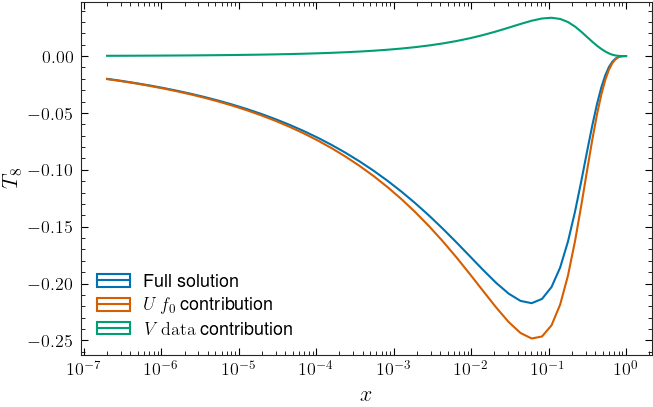

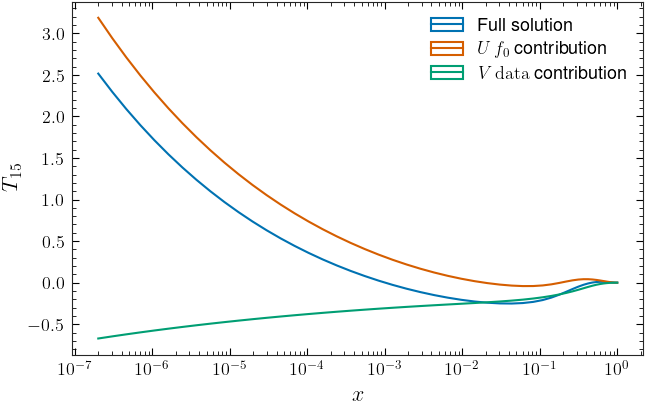

In [5]:
replica = 1
figs = list(plot_grids(
    [full, u_contrib, v_contrib],
    flavours=DEFAULT_FLAVOURS,
    ylabels=DEFAULT_YLABELS,
    labels=["Full solution", r"$U\,f_0$ contribution", r"$V\,\mathrm{data}$ contribution"],
    plot_provider="line",
    plot_args=[{"replicas": [replica]}] * 3,
    xscale="log",
))
for fig in figs:
    display(fig)

## Effect of the choice of `f0`

The full solution with `f0 = ` network at **initialisation** vs `f0 = ` network at the
**reference epoch**. (Only the U contribution depends on `f0`; the V contribution is
the same.)

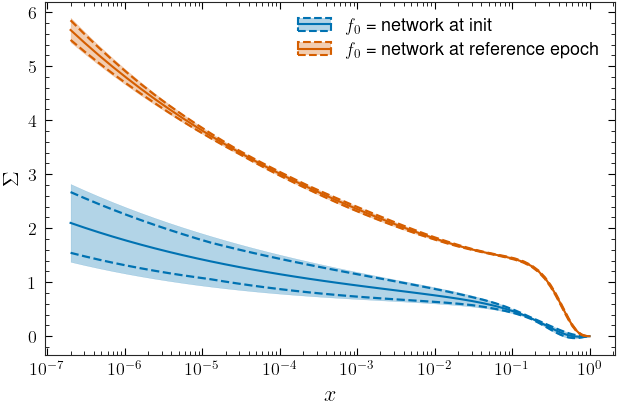

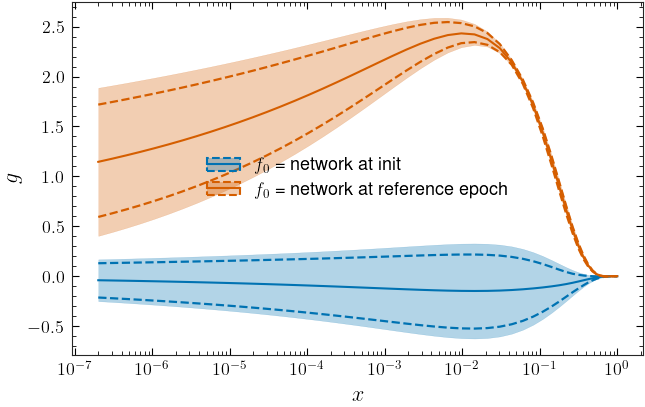

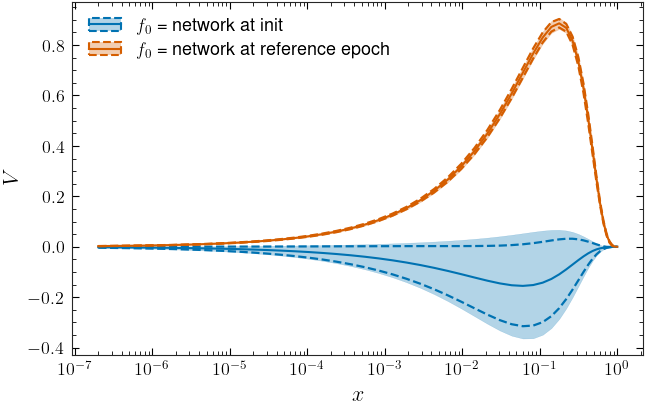

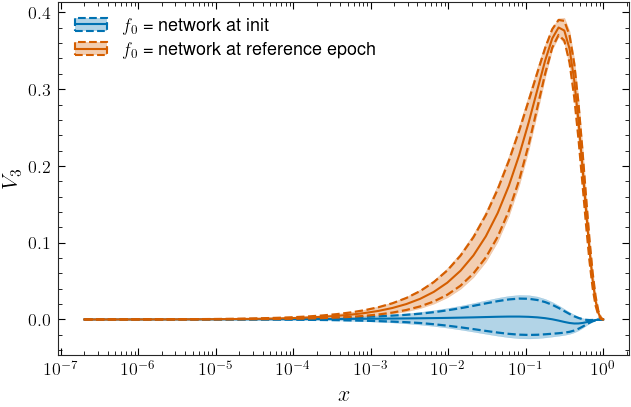

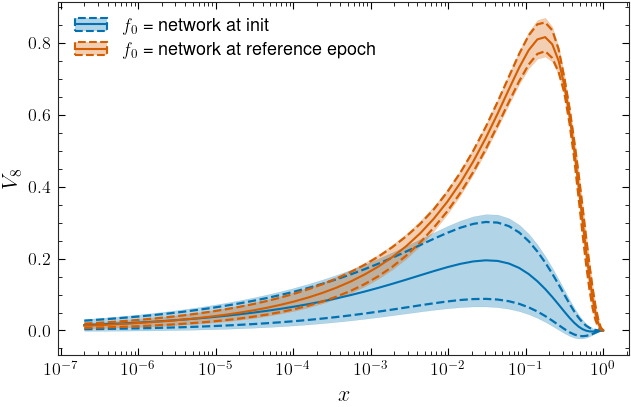

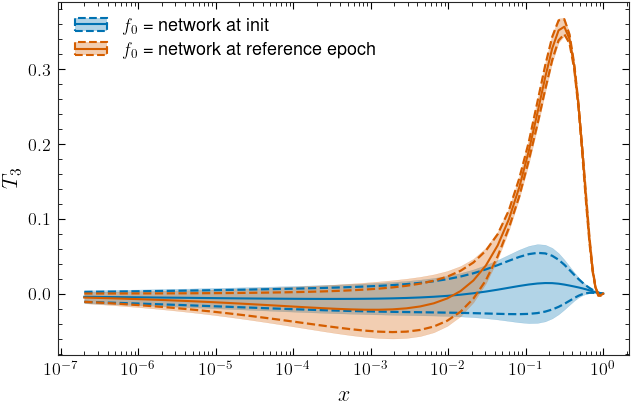

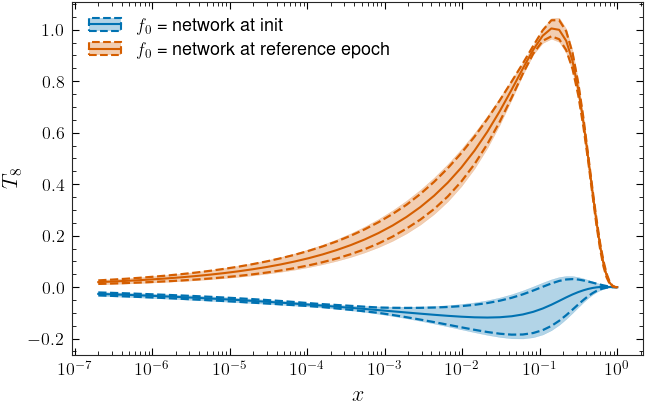

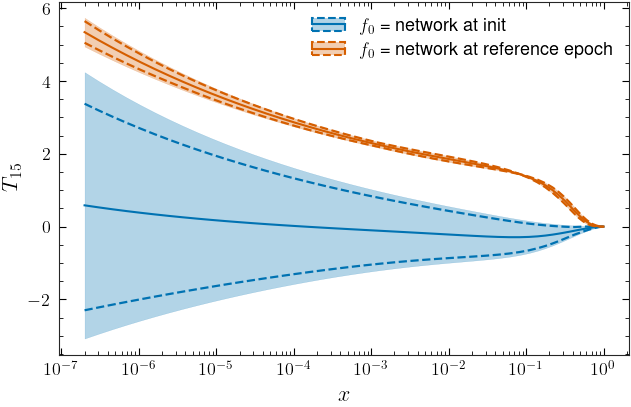

In [6]:
full_ref = evo.plotting_grid(t, data_tr, f0_ref)

figs = list(plot_grids(
    [full, full_ref],
    flavours=DEFAULT_FLAVOURS,
    ylabels=DEFAULT_YLABELS,
    labels=[r"$f_0$ = network at init", r"$f_0$ = network at reference epoch"],
    plot_provider="bounds",
    xscale="log",
))
for fig in figs:
    display(fig)